## Data Prep

In [9]:
import os
import urllib.request
import zipfile
import pandas as pd

## Define Paths

In [10]:
url = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"
zip_path = "ml-1m.zip"
extract_dir = "."

## Download the dataset if it is not present

In [11]:
if not os.path.exists(zip_path) and not os.path.exists("ml-1m"):
    print("Downloading MovieLens 1M dataset...")
    urllib.request.urlretrieve(url, zip_path)
    print("Download complete.")

## Extract the zip container

In [12]:
if os.path.exists(zip_path) and not os.path.exists("ml-1m"):
    print("Extracting files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete.")

## Ingest ratings file into memory

In [13]:
# Load all data into pandas for test
data = pd.read_csv(
    'ml-1m/movies.dat', 
    sep='::', 
    engine='python',
    encoding='latin-1',
    names=['movie_id', 'title', 'genres']
    )
print("Data ingestion successful.")

Data ingestion successful.


In [14]:
print(f"Data shape: {data.shape}")
print(f"Data columns: {data.columns.tolist()}")
print(f"First 5 rows:\n{data.head()}")

Data shape: (3883, 3)
Data columns: ['movie_id', 'title', 'genres']
First 5 rows:
   movie_id                               title                        genres
0         1                    Toy Story (1995)   Animation|Children's|Comedy
1         2                      Jumanji (1995)  Adventure|Children's|Fantasy
2         3             Grumpier Old Men (1995)                Comedy|Romance
3         4            Waiting to Exhale (1995)                  Comedy|Drama
4         5  Father of the Bride Part II (1995)                        Comedy


In [15]:
print("Loading data into Pandas...")
ratings = pd.read_csv(
    'ml-1m/ratings.dat', 
    sep='::', 
    engine='python',
    names=['user_id', 'item_id', 'rating', 'timestamp']
)
print("Data ingestion successful.")


Loading data into Pandas...
Data ingestion successful.


## Verification Check

In [16]:
print(f"Total dataset rows loaded: {ratings.shape[0]}")
assert ratings.shape[0] == 1000209, "Row count mismatch. Expected 1,000,209 rows."
ratings.head()

Total dataset rows loaded: 1000209


,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


# Binarize, Time-Split, and Convert to Sparse Matrix

In [17]:
import numpy as np
from scipy.sparse import csr_matrix

In [18]:
# 1. Binarize: Filter to keep only ratings >= 4 as positive feedback signals
liked_ratings = ratings[ratings['rating'] >= 4].copy()

# 2. Sort interactions chronologically per user
liked_ratings = liked_ratings.sort_values(by=['user_id', 'timestamp'])

# Print result
print(liked_ratings.head())


    user_id  item_id  rating  timestamp
31        1     3186       4  978300019
22        1     1270       5  978300055
27        1     1721       4  978300055
37        1     1022       5  978300055
36        1     1836       5  978300172


In [19]:

# 3. Code IDs into continuous, zero-indexed categories for clean matrix alignment
liked_ratings['user_code'] = liked_ratings['user_id'].astype('category').cat.codes
liked_ratings['item_code'] = liked_ratings['item_id'].astype('category').cat.codes

num_users = liked_ratings['user_code'].max() + 1
num_items = liked_ratings['item_code'].max() + 1

# Print result
print(liked_ratings.head(), end="\n\n")

    user_id  item_id  rating  timestamp  user_code  item_code
31        1     3186       4  978300019          0       2837
22        1     1270       5  978300055          0       1113
27        1     1721       4  978300055          0       1490
37        1     1022       5  978300055          0        904
36        1     1836       5  978300172          0       1570



In [20]:
print(liked_ratings.groupby('user_code'))

In [21]:
# 4. Chronological train/test split (80% train, 20% test per user)
train_rows, train_cols = [], []
test_rows, test_cols = [], []

for user_code, group in liked_ratings.groupby('user_code'):
    n_interactions = len(group)
    split_idx = int(n_interactions * 0.8)
    
    user_items = group['item_code'].values
    
    train_rows.extend([user_code] * split_idx)
    train_cols.extend(user_items[:split_idx])
    
    test_rows.extend([user_code] * (n_interactions - split_idx))
    test_cols.extend(user_items[split_idx:])

# 5. Build the final SciPy Compressed Sparse Row Matrices
train_matrix = csr_matrix((np.ones(len(train_rows)), (train_rows, train_cols)), shape=(num_users, num_items))
test_matrix = csr_matrix((np.ones(len(test_rows)), (test_rows, test_cols)), shape=(num_users, num_items))

# Verification Check
print(f"Training matrix layout: {train_matrix.shape}")
print(f"Total sparse training values (nnz): {train_matrix.nnz:,}")
print(f"Total sparse testing values (nnz): {test_matrix.nnz:,}")
print(f"Data type verification: {type(train_matrix)}")

assert isinstance(train_matrix, csr_matrix), "Matrix conversion failed to yield a CSR matrix object."

Training matrix layout: (6038, 3533)
Total sparse training values (nnz): 457,818
Total sparse testing values (nnz): 117,463
Data type verification: <class 'scipy.sparse._csr.csr_matrix'>


## Compute Gini and Plot Long Tail Distribution


To calculate the Gini coefficient (used it to quantify popularity bias and exposure inequality in recommendation systems.), you plot a Lorenz curve. Imagine sorting all the movies in your dataset from the least popular to the most popular along the bottom axis, and tracking the cumulative percentage of total ratings they receive along the vertical axis.

- **Line of Equality (45-degree diagonal):** This represents a perfectly fair system. If you have 1,000 movies, the bottom 10% of movies get exactly 10% of all ratings, the bottom 50% get 50% of the ratings, and so on. In this scenario, the Gini coefficient is 0.0.

- **The Lorenz Curve** This is the actual path your real-world data takes. Because a few blockbuster movies dominate your dataset while thousands of indie movies get almost no attention, the curve sags deeply away from the diagonal line.

- **Absolute Inequality:** If one single movie captured every single rating in the entire dataset while all other movies received zero, the curve would run flat along the bottom axis and shoot straight up at the very end. In this scenario, the Gini coefficient is 1.0.

Matplotlib is building the font cache; this may take a moment.


Total Unique Items tracked: 3,533
Baseline Gini Coefficient: 0.7176
Concentration Metric: The top 5% of movies account for 37.43% of all training interactions.


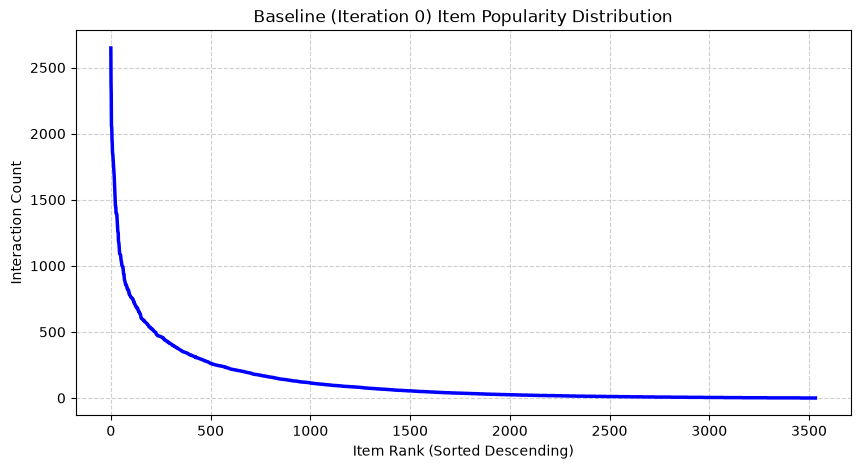

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Gini Coefficient Function
# Measures the inequality of a distribution. 0 = perfect equality, 1 = absolute inequality.
def compute_gini(exposure_counts):
    x = np.sort(exposure_counts)
    n = len(x)
    cum = np.cumsum(x)
    if cum[-1] == 0:
        return 0.0
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n

# 2. Calculates exactly how many times each movie was interacted with in the training set.
# train_matrix.sum(axis=0) returns a 2D matrix of shape (1, num_items)
item_popularity = np.array(train_matrix.sum(axis=0)).flatten()

# 3. Sort item popularity in descending order (highest popularity first)
sorted_popularity = np.sort(item_popularity)[::-1]

# 4. Calculate baseline concentration metrics
total_interactions = sorted_popularity.sum()
top_5_percent_cutoff = int(len(sorted_popularity) * 0.05)
interactions_in_top_5 = sorted_popularity[:top_5_percent_cutoff].sum()
percentage_concentration = (interactions_in_top_5 / total_interactions) * 100

gini_score = compute_gini(item_popularity)

# 5. Output Verification Checkpoints
print(f"Total Unique Items tracked: {len(item_popularity):,}")
print(f"Baseline Gini Coefficient: {gini_score:.4f}")
print(f"Concentration Metric: The top 5% of movies account for {percentage_concentration:.2f}% of all training interactions.")

# 6. Plot the Raw Long-Tail Distribution
plt.figure(figsize=(10, 5))
sns.lineplot(data=sorted_popularity, color='blue', linewidth=2.5)
plt.title("Baseline (Iteration 0) Item Popularity Distribution")
plt.xlabel("Item Rank (Sorted Descending)")
plt.ylabel("Interaction Count")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()